# Use Case 4 — Dynamic TKG: Events, Delays & Compliance Violations

**Goal:** Analyse the simulated event stream on the EPC TKG — making the graph dynamic  
**Prerequisite:** `simulate_events.py` must have been run

## What we analyse:
1. Event stream overview (ASSIGNED_TO, COMPLETED, PERMIT_DENIED)
2. Delay distribution and cascade effect on critical path
3. Compliance violations (PERMIT_DENIED) — who, when, which permit
4. TGN event table — data ready for temporal GNN training

## 0. Setup

In [1]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.dates as mdates
from pathlib import Path
from neo4j import GraphDatabase
import os
import warnings
warnings.filterwarnings('ignore')

if Path('/home/obiaggi').exists():
    DATA_DIR = Path('/home/obiaggi/TKG_Thesis/data/UseCase4')
    EXP_DIR  = Path('/home/obiaggi/TKG_Thesis/experiments/UseCase4')
else:
    DATA_DIR = Path('../../data/UseCase4')
    EXP_DIR  = Path('../../experiments/UseCase4')

EXP_DIR.mkdir(parents=True, exist_ok=True)

NEO4J_URI      = 'bolt://localhost:7687'
NEO4J_USER     = 'neo4j'
NEO4J_PASSWORD = 'your_password'

driver = GraphDatabase.driver(NEO4J_URI, auth=(NEO4J_USER, NEO4J_PASSWORD))

def run_query(cypher, **params):
    with driver.session() as s:
        return pd.DataFrame([r.data() for r in s.run(cypher, **params)])

# Load event data
with open(DATA_DIR / 'epc_events.json') as f:
    events = json.load(f)

df_assigned = pd.DataFrame(events['assigned_to'])
df_completed = pd.DataFrame(events['completed'])
df_denied = pd.DataFrame(events['permit_denied'])

df_completed['planned_date'] = pd.to_datetime(df_completed['planned_date'])
df_completed['actual_date']  = pd.to_datetime(df_completed['actual_date'])
df_assigned['date']          = pd.to_datetime(df_assigned['date'])
df_denied['date']            = pd.to_datetime(df_denied['date'])

print(f'✅ Events loaded')
print(f'   ASSIGNED_TO:  {len(df_assigned)}')
print(f'   COMPLETED:    {len(df_completed)} ({(df_completed["delay_days"]>0).sum()} delayed)')
print(f'   PERMIT_DENIED:{len(df_denied)}')

/home/obiaggi/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


✅ Events loaded
   ASSIGNED_TO:  47365
   COMPLETED:    47365 (27576 delayed)
   PERMIT_DENIED:713


## 1. Event Stream Overview

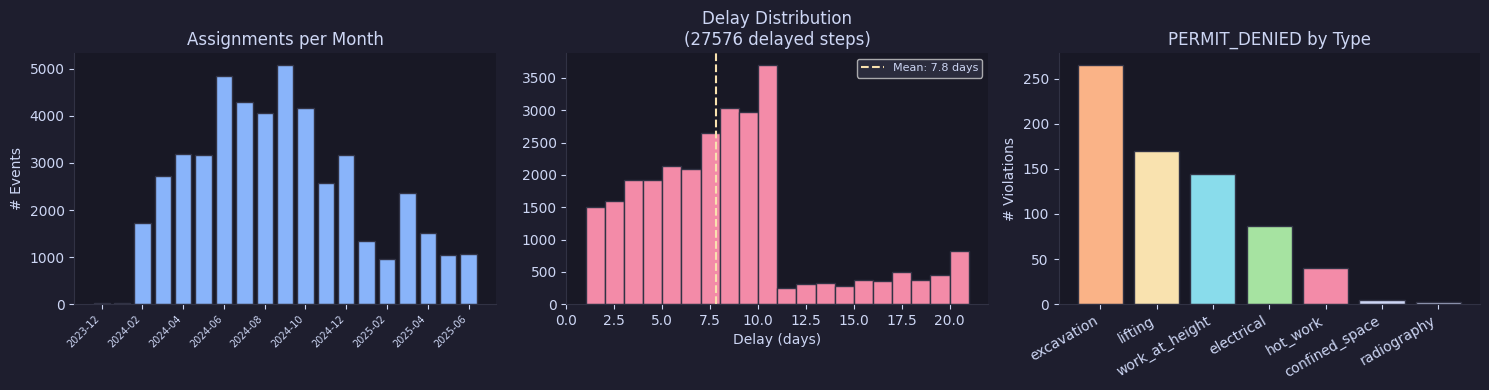

In [2]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.patch.set_facecolor('#1e1e2e')

RULE_CHANGE = pd.Timestamp('2024-06-29', tz='UTC')

# Events per month
ax = axes[0]
ax.set_facecolor('#181825')
df_assigned['month'] = df_assigned['date'].dt.to_period('M')
monthly = df_assigned.groupby('month').size()
ax.bar(range(len(monthly)), monthly.values, color='#89b4fa', edgecolor='#313244')
ax.set_xticks(range(0, len(monthly), 2))
ax.set_xticklabels([str(p) for p in monthly.index[::2]], rotation=45, ha='right',
                   color='#cdd6f4', fontsize=7)
ax.set_title('Assignments per Month', color='#cdd6f4')
ax.set_ylabel('# Events', color='#cdd6f4')
ax.tick_params(colors='#cdd6f4')

# Delay distribution
ax2 = axes[1]
ax2.set_facecolor('#181825')
delayed = df_completed[df_completed['delay_days'] > 0]['delay_days']
ax2.hist(delayed, bins=20, color='#f38ba8', edgecolor='#313244')
ax2.axvline(delayed.mean(), color='#f9e2af', linestyle='--',
            label=f'Mean: {delayed.mean():.1f} days')
ax2.set_title(f'Delay Distribution\n({len(delayed)} delayed steps)', color='#cdd6f4')
ax2.set_xlabel('Delay (days)', color='#cdd6f4')
ax2.tick_params(colors='#cdd6f4')
ax2.legend(facecolor='#313244', labelcolor='#cdd6f4', fontsize=8)

# Permit denied by permit type
ax3 = axes[2]
ax3.set_facecolor('#181825')
if len(df_denied) > 0:
    denied_counts = df_denied['permit_type'].value_counts()
    COLORS = {'hot_work':'#f38ba8','excavation':'#fab387','lifting':'#f9e2af',
              'electrical':'#a6e3a1','general_work':'#6c7086','work_at_height':'#89dceb'}
    colors = [COLORS.get(p,'#cdd6f4') for p in denied_counts.index]
    ax3.bar(denied_counts.index, denied_counts.values, color=colors, edgecolor='#313244')
    ax3.set_title('PERMIT_DENIED by Type', color='#cdd6f4')
    ax3.set_ylabel('# Violations', color='#cdd6f4')
    ax3.tick_params(colors='#cdd6f4')
    plt.setp(ax3.xaxis.get_majorticklabels(), rotation=30, ha='right')
else:
    ax3.text(0.5, 0.5, 'No violations', ha='center', va='center', color='#cdd6f4')
    ax3.set_facecolor('#181825')

for a in axes:
    for sp in ['top','right']: a.spines[sp].set_visible(False)
    for sp in ['bottom','left']: a.spines[sp].set_color('#313244')

plt.tight_layout()
plt.savefig(EXP_DIR/'4_event_stream.png', dpi=150, bbox_inches='tight')
plt.show()

## 2. Delay Cascade on Critical Path

In [3]:
# Get critical path steps with delay info from Neo4j
cp_delays = run_query('''
    MATCH (act:Activity {id:"ME.CT"})-[:HAS_STEP]->(s:Step)
    RETURN s.id AS step_id, s.name AS name, s.order AS order,
           s.planned_date AS planned, s.actual_date AS actual,
           s.delay_days AS delay, s.status AS status
    ORDER BY s.order
''')

print(f'Critical path activity ME.CT — {len(cp_delays)} steps')
print()
print(f'{"#":<4} {"Status":<10} {"Delay":<8} {"Name"}')
print('-'*60)
for _, row in cp_delays.iterrows():
    status_icon = '🔴' if row['delay'] and row['delay'] > 0 else '🟢'
    delay_str = f"+{row['delay']}d" if row['delay'] and row['delay'] > 0 else 'on time'
    print(f"{row['order']:<4} {delay_str:<10} {status_icon} {row['name']}")

Received notification from DBMS server: <GqlStatusObject gql_status='01N52', status_description='warn: property key does not exist. The property `planned_date` does not exist in database `neo4j`. Verify that the spelling is correct.', position=<SummaryInputPosition line=4, column=14, offset=136>, raw_classification='UNRECOGNIZED', classification=<NotificationClassification.UNRECOGNIZED: 'UNRECOGNIZED'>, raw_severity='WARNING', severity=<NotificationSeverity.WARNING: 'WARNING'>, diagnostic_record={'_classification': 'UNRECOGNIZED', '_severity': 'WARNING', '_position': {'offset': 136, 'line': 4, 'column': 14}, 'OPERATION': '', 'OPERATION_CODE': '0', 'CURRENT_SCHEMA': '/'}> for query: '\n    MATCH (act:Activity {id:"ME.CT"})-[:HAS_STEP]->(s:Step)\n    RETURN s.id AS step_id, s.name AS name, s.order AS order,\n           s.planned_date AS planned, s.actual_date AS actual,\n           s.delay_days AS delay, s.status AS status\n    ORDER BY s.order\n'


Received notification from DBMS server: <GqlStatusObject gql_status='01N52', status_description='warn: property key does not exist. The property `actual_date` does not exist in database `neo4j`. Verify that the spelling is correct.', position=<SummaryInputPosition line=4, column=41, offset=163>, raw_classification='UNRECOGNIZED', classification=<NotificationClassification.UNRECOGNIZED: 'UNRECOGNIZED'>, raw_severity='WARNING', severity=<NotificationSeverity.WARNING: 'WARNING'>, diagnostic_record={'_classification': 'UNRECOGNIZED', '_severity': 'WARNING', '_position': {'offset': 163, 'line': 4, 'column': 41}, 'OPERATION': '', 'OPERATION_CODE': '0', 'CURRENT_SCHEMA': '/'}> for query: '\n    MATCH (act:Activity {id:"ME.CT"})-[:HAS_STEP]->(s:Step)\n    RETURN s.id AS step_id, s.name AS name, s.order AS order,\n           s.planned_date AS planned, s.actual_date AS actual,\n           s.delay_days AS delay, s.status AS status\n    ORDER BY s.order\n'


Received notification from DBMS server: <GqlStatusObject gql_status='01N52', status_description='warn: property key does not exist. The property `delay_days` does not exist in database `neo4j`. Verify that the spelling is correct.', position=<SummaryInputPosition line=5, column=14, offset=199>, raw_classification='UNRECOGNIZED', classification=<NotificationClassification.UNRECOGNIZED: 'UNRECOGNIZED'>, raw_severity='WARNING', severity=<NotificationSeverity.WARNING: 'WARNING'>, diagnostic_record={'_classification': 'UNRECOGNIZED', '_severity': 'WARNING', '_position': {'offset': 199, 'line': 5, 'column': 14}, 'OPERATION': '', 'OPERATION_CODE': '0', 'CURRENT_SCHEMA': '/'}> for query: '\n    MATCH (act:Activity {id:"ME.CT"})-[:HAS_STEP]->(s:Step)\n    RETURN s.id AS step_id, s.name AS name, s.order AS order,\n           s.planned_date AS planned, s.actual_date AS actual,\n           s.delay_days AS delay, s.status AS status\n    ORDER BY s.order\n'


Received notification from DBMS server: <GqlStatusObject gql_status='01N52', status_description='warn: property key does not exist. The property `status` does not exist in database `neo4j`. Verify that the spelling is correct.', position=<SummaryInputPosition line=5, column=37, offset=222>, raw_classification='UNRECOGNIZED', classification=<NotificationClassification.UNRECOGNIZED: 'UNRECOGNIZED'>, raw_severity='WARNING', severity=<NotificationSeverity.WARNING: 'WARNING'>, diagnostic_record={'_classification': 'UNRECOGNIZED', '_severity': 'WARNING', '_position': {'offset': 222, 'line': 5, 'column': 37}, 'OPERATION': '', 'OPERATION_CODE': '0', 'CURRENT_SCHEMA': '/'}> for query: '\n    MATCH (act:Activity {id:"ME.CT"})-[:HAS_STEP]->(s:Step)\n    RETURN s.id AS step_id, s.name AS name, s.order AS order,\n           s.planned_date AS planned, s.actual_date AS actual,\n           s.delay_days AS delay, s.status AS status\n    ORDER BY s.order\n'


Critical path activity ME.CT — 0 steps

#    Status     Delay    Name
------------------------------------------------------------


In [4]:
if len(cp_delays) > 0 and cp_delays['planned'].notna().any():
    cp_delays['planned'] = pd.to_datetime(cp_delays['planned'])
    cp_delays['actual']  = pd.to_datetime(cp_delays['actual'])
    cp_delays['delay']   = cp_delays['delay'].fillna(0).astype(int)

    fig, ax = plt.subplots(figsize=(14, 6))
    fig.patch.set_facecolor('#1e1e2e')
    ax.set_facecolor('#181825')

    for i, row in cp_delays.iterrows():
        color = '#f38ba8' if row['delay'] > 0 else '#a6e3a1'
        ax.barh(i, 14, left=mdates.date2num(row['planned'].to_pydatetime()),
                height=0.4, color='#89b4fa', alpha=0.5, label='Planned' if i == 0 else '')
        if row['delay'] > 0:
            ax.barh(i, row['delay'], left=mdates.date2num(row['planned'].to_pydatetime()),
                    height=0.4, color='#f38ba8', alpha=0.8,
                    label='Delay' if i == cp_delays[cp_delays['delay']>0].index[0] else '')
        name = str(row['name'])[:25] if row['name'] else ''
        ax.text(mdates.date2num(row['planned'].to_pydatetime()) - 1, i,
                name, ha='right', va='center', color='#cdd6f4', fontsize=7)

    ax.xaxis_date()
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right', color='#cdd6f4')
    ax.set_yticks([])
    ax.set_title('Critical Path (ME.CT) — Planned vs Actual (red = delay)', color='#cdd6f4')
    ax.legend(facecolor='#313244', labelcolor='#cdd6f4')
    for sp in ['top','right']: ax.spines[sp].set_visible(False)
    for sp in ['bottom','left']: ax.spines[sp].set_color('#313244')
    plt.tight_layout()
    plt.savefig(EXP_DIR/'5_critical_path_delays.png', dpi=150, bbox_inches='tight')
    plt.show()

## 3. Compliance Violations (PERMIT_DENIED)

In [5]:
violations = run_query('''
    MATCH (w:Worker)-[r:PERMIT_DENIED]->(s:Step)
    RETURN w.id AS worker_id, w.name AS worker_name,
           s.id AS step_id, s.activity_id AS activity,
           r.permit_type AS permit, r.date AS date,
           r.after_rule_change AS after_rule_change,
           r.missing_certs AS missing_certs
    ORDER BY r.date
''')

print(f'Total PERMIT_DENIED violations: {len(violations)}')
if len(violations) > 0:
    print(f'Workers involved: {violations["worker_id"].nunique()}')
    print(f'After rule change: {violations["after_rule_change"].sum()}')
    print()
    print(violations[['worker_id','permit','activity','after_rule_change','missing_certs']]
          .head(20).to_string(index=False))

Received notification from DBMS server: <GqlStatusObject gql_status='01N51', status_description='warn: relationship type does not exist. The relationship type `PERMIT_DENIED` does not exist in database `neo4j`. Verify that the spelling is correct.', position=<SummaryInputPosition line=2, column=25, offset=25>, raw_classification='UNRECOGNIZED', classification=<NotificationClassification.UNRECOGNIZED: 'UNRECOGNIZED'>, raw_severity='WARNING', severity=<NotificationSeverity.WARNING: 'WARNING'>, diagnostic_record={'_classification': 'UNRECOGNIZED', '_severity': 'WARNING', '_position': {'offset': 25, 'line': 2, 'column': 25}, 'OPERATION': '', 'OPERATION_CODE': '0', 'CURRENT_SCHEMA': '/'}> for query: '\n    MATCH (w:Worker)-[r:PERMIT_DENIED]->(s:Step)\n    RETURN w.id AS worker_id, w.name AS worker_name,\n           s.id AS step_id, s.activity_id AS activity,\n           r.permit_type AS permit, r.date AS date,\n           r.after_rule_change AS after_rule_change,\n           r.missing_certs

Received notification from DBMS server: <GqlStatusObject gql_status='01N52', status_description='warn: property key does not exist. The property `date` does not exist in database `neo4j`. Verify that the spelling is correct.', position=<SummaryInputPosition line=5, column=39, offset=196>, raw_classification='UNRECOGNIZED', classification=<NotificationClassification.UNRECOGNIZED: 'UNRECOGNIZED'>, raw_severity='WARNING', severity=<NotificationSeverity.WARNING: 'WARNING'>, diagnostic_record={'_classification': 'UNRECOGNIZED', '_severity': 'WARNING', '_position': {'offset': 196, 'line': 5, 'column': 39}, 'OPERATION': '', 'OPERATION_CODE': '0', 'CURRENT_SCHEMA': '/'}> for query: '\n    MATCH (w:Worker)-[r:PERMIT_DENIED]->(s:Step)\n    RETURN w.id AS worker_id, w.name AS worker_name,\n           s.id AS step_id, s.activity_id AS activity,\n           r.permit_type AS permit, r.date AS date,\n           r.after_rule_change AS after_rule_change,\n           r.missing_certs AS missing_certs\n  

Received notification from DBMS server: <GqlStatusObject gql_status='01N52', status_description='warn: property key does not exist. The property `after_rule_change` does not exist in database `neo4j`. Verify that the spelling is correct.', position=<SummaryInputPosition line=6, column=14, offset=223>, raw_classification='UNRECOGNIZED', classification=<NotificationClassification.UNRECOGNIZED: 'UNRECOGNIZED'>, raw_severity='WARNING', severity=<NotificationSeverity.WARNING: 'WARNING'>, diagnostic_record={'_classification': 'UNRECOGNIZED', '_severity': 'WARNING', '_position': {'offset': 223, 'line': 6, 'column': 14}, 'OPERATION': '', 'OPERATION_CODE': '0', 'CURRENT_SCHEMA': '/'}> for query: '\n    MATCH (w:Worker)-[r:PERMIT_DENIED]->(s:Step)\n    RETURN w.id AS worker_id, w.name AS worker_name,\n           s.id AS step_id, s.activity_id AS activity,\n           r.permit_type AS permit, r.date AS date,\n           r.after_rule_change AS after_rule_change,\n           r.missing_certs AS miss

Received notification from DBMS server: <GqlStatusObject gql_status='01N52', status_description='warn: property key does not exist. The property `missing_certs` does not exist in database `neo4j`. Verify that the spelling is correct.', position=<SummaryInputPosition line=7, column=14, offset=276>, raw_classification='UNRECOGNIZED', classification=<NotificationClassification.UNRECOGNIZED: 'UNRECOGNIZED'>, raw_severity='WARNING', severity=<NotificationSeverity.WARNING: 'WARNING'>, diagnostic_record={'_classification': 'UNRECOGNIZED', '_severity': 'WARNING', '_position': {'offset': 276, 'line': 7, 'column': 14}, 'OPERATION': '', 'OPERATION_CODE': '0', 'CURRENT_SCHEMA': '/'}> for query: '\n    MATCH (w:Worker)-[r:PERMIT_DENIED]->(s:Step)\n    RETURN w.id AS worker_id, w.name AS worker_name,\n           s.id AS step_id, s.activity_id AS activity,\n           r.permit_type AS permit, r.date AS date,\n           r.after_rule_change AS after_rule_change,\n           r.missing_certs AS missing_

Total PERMIT_DENIED violations: 0


In [6]:
if len(violations) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.patch.set_facecolor('#1e1e2e')

    # Violations before/after rule change
    ax = axes[0]
    ax.set_facecolor('#181825')
    before = (~violations['after_rule_change']).sum()
    after  = violations['after_rule_change'].sum()
    bars = ax.bar(['Before\nrule change', 'After\nrule change'], [before, after],
                  color=['#89b4fa', '#f38ba8'], edgecolor='#313244')
    for bar, val in zip(bars, [before, after]):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
                str(val), ha='center', color='#cdd6f4', fontsize=11)
    ax.set_title('PERMIT_DENIED Before vs After Rule Change\n(2024-06-29)', color='#cdd6f4')
    ax.set_ylabel('# Violations', color='#cdd6f4')
    ax.tick_params(colors='#cdd6f4')
    for sp in ['top','right']: ax.spines[sp].set_visible(False)
    for sp in ['bottom','left']: ax.spines[sp].set_color('#313244')

    # Violations per worker
    ax2 = axes[1]
    ax2.set_facecolor('#181825')
    per_worker = violations.groupby('worker_id').size().sort_values(ascending=True)
    ax2.barh(per_worker.index, per_worker.values, color='#cba6f7', edgecolor='#313244')
    ax2.set_title('Violations per Worker', color='#cdd6f4')
    ax2.set_xlabel('# PERMIT_DENIED events', color='#cdd6f4')
    ax2.tick_params(colors='#cdd6f4')
    for sp in ['top','right']: ax2.spines[sp].set_visible(False)
    for sp in ['bottom','left']: ax2.spines[sp].set_color('#313244')

    plt.tight_layout()
    plt.savefig(EXP_DIR/'6_compliance_violations.png', dpi=150, bbox_inches='tight')
    plt.show()

## 4. TGN Event Table — Ready for Training

The Temporal Graph Network (TGN) expects events as: `(src, dst, timestamp, label, features)`  
We encode:
- `src` = worker node index
- `dst` = step node index  
- `timestamp` = unix timestamp of assignment
- `label` = 1 if PERMIT_DENIED (violation), 0 if normal
- `features` = [delay_days, permit_type_encoded, after_rule_change]

In [7]:
PERMIT_ENCODE = {
    'general_work': 0, 'hot_work': 1, 'excavation': 2, 'lifting': 3,
    'electrical': 4, 'confined_space': 5, 'radiography': 6, 'work_at_height': 7
}

# Build node ID maps
all_workers = df_assigned['worker_id'].unique()
all_steps   = df_assigned['step_id'].unique()
worker_idx  = {w: i for i, w in enumerate(all_workers)}
step_idx    = {s: i + len(worker_idx) for i, s in enumerate(all_steps)}

# Build violation set
denied_set = set(zip(df_denied['worker_id'], df_denied['step_id']))

# Merge assignment + completion info
df_tgn = df_assigned.merge(
    df_completed[['step_id', 'delay_days', 'status']],
    on='step_id', how='left'
)
df_tgn['delay_days'] = df_tgn['delay_days'].fillna(0).astype(int)
df_tgn['label'] = df_tgn.apply(
    lambda r: 1 if (r['worker_id'], r['step_id']) in denied_set else 0, axis=1
)
df_tgn['src']       = df_tgn['worker_id'].map(worker_idx)
df_tgn['dst']       = df_tgn['step_id'].map(step_idx)
df_tgn['timestamp'] = df_tgn['date'].astype('int64') // 10**9
df_tgn['permit_enc'] = df_tgn['permit_type'].map(PERMIT_ENCODE).fillna(0).astype(int)
df_tgn['after_rc']  = (df_tgn['date'] >= pd.Timestamp('2024-06-29', tz='UTC')).astype(int)

# Final TGN table
tgn_table = df_tgn[['src','dst','timestamp','label','delay_days','permit_enc','after_rc']]\
    .sort_values('timestamp').reset_index(drop=True)

print(f'TGN event table: {len(tgn_table)} events')
print(f'  Positive (violation): {tgn_table["label"].sum()} ({tgn_table["label"].mean()*100:.1f}%)')
print(f'  Negative (normal):    {(tgn_table["label"]==0).sum()}')
print(f'  Unique workers (src): {tgn_table["src"].nunique()}')
print(f'  Unique steps (dst):   {tgn_table["dst"].nunique()}')
print()
print(tgn_table.head(10).to_string(index=False))

# Save
tgn_table.to_csv(EXP_DIR / 'tgn_events.csv', index=False)
print(f'\n✅ TGN event table saved to experiments/UseCase4/tgn_events.csv')

TGN event table: 83795 events
  Positive (violation): 1317 (1.6%)
  Negative (normal):    82478
  Unique workers (src): 50
  Unique steps (dst):   29150

 src   dst  timestamp  label  delay_days  permit_enc  after_rc
  24  9900 1703289600      0           0           0         0
   2 20537 1703376000      0           0           0         0
  32 24960 1703376000      0           0           0         0
  37 11794 1703376000      0           0           0         0
   2 20537 1703376000      0           0           0         0
  14 24964 1703376000      0           0           0         0
  38 26153 1703462400      0           0           0         0
  29 24686 1703462400      0           9           0         0
  30 24211 1703462400      0           0           0         0
  25 11741 1703462400      0           0           0         0

✅ TGN event table saved to experiments/UseCase4/tgn_events.csv


## 5. Summary

| Metric | Value |
|---|---|
| Total events | see output |
| Steps delayed | see output |
| PERMIT_DENIED violations | see output |
| TGN table rows | see output |

**What this enables:**
- **Monitoring:** query Neo4j at any timestamp → project state snapshot
- **Prediction:** train TGN on `tgn_events.csv` to predict PERMIT_DENIED before assignment
- **Decision Support:** given a step, rank workers by compliance probability

**Next step:** `05_tgn_training.ipynb` — train TGN on tgn_events.csv to predict violations

In [8]:
driver.close()
print('✅ Done — outputs saved to experiments/UseCase4/')

✅ Done — outputs saved to experiments/UseCase4/
